In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:

!pip install -q torch torchvision datasets pillow tqdm pandas numpy scikit-learn git+https://github.com/openai/CLIP.git

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.8 MB/s eta 0:00:00


In [23]:
import os
import random
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image, ImageFile

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

import clip

ImageFile.LOAD_TRUNCATED_IMAGES = True

In [26]:
import os
os.chdir("/content/drive/MyDrive/UHD-IQA-database")

In [49]:
# =========================
# CONFIG
# =========================
from pathlib import Path

CSV_PATH = "uhd-iqa-metadata.csv"

IMAGE_ROOT = Path("/content/drive/MyDrive/UHD-IQA-database")

EMBED_CACHE_ROOT = Path("./clip_cache_uhd_iqa")

PRETRAINED_WEIGHTS_PATH = Path("pretrained.pth")

OUTPUT_DIR = Path("./uhd_iqa_finetune_runs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
EMBED_CACHE_ROOT.mkdir(parents=True, exist_ok=True)

# Training
BATCH_SIZE = 1024
EPOCHS = 20
LR = 1e-4
NUM_WORKERS = 0
SEED = 42

# CLIP model
CLIP_MODEL_NAME = "ViT-L/14"

IMAGE_COL = "image_name"
TARGET_COL = "quality_mos"
SPLIT_COL = "set"

device = "cuda" if __import__("torch").cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cuda


In [24]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)


def rankdata(a: np.ndarray) -> np.ndarray:
    a = np.asarray(a)
    sorter = np.argsort(a, kind="mergesort")
    inv = np.empty_like(sorter)
    inv[sorter] = np.arange(len(a))

    a_sorted = a[sorter]
    obs = np.r_[True, a_sorted[1:] != a_sorted[:-1]]
    dense_rank = obs.cumsum() - 1

    counts = np.bincount(dense_rank)
    cumulative = np.cumsum(counts)
    starts = cumulative - counts
    avg_ranks = (starts + cumulative - 1) / 2.0 + 1.0
    return avg_ranks[dense_rank][inv]


def pearson_corr(x: np.ndarray, y: np.ndarray) -> float:
    x = x.astype(np.float64)
    y = y.astype(np.float64)
    x = x - x.mean()
    y = y - y.mean()
    denom = np.sqrt((x ** 2).sum()) * np.sqrt((y ** 2).sum())
    if denom == 0:
        return float("nan")
    return float((x * y).sum() / denom)


def spearman_corr(x: np.ndarray, y: np.ndarray) -> float:
    return pearson_corr(rankdata(x), rankdata(y))

In [34]:
df = pd.read_csv(CSV_PATH)
print(df.head())
print(df.columns.tolist())
print(df[SPLIT_COL].value_counts(dropna=False))
print(df[SPLIT_COL].unique())

df[IMAGE_COL] = df[IMAGE_COL].astype(str)
df[TARGET_COL] = df[TARGET_COL].astype(float)
df[SPLIT_COL] = df[SPLIT_COL].astype(str).str.strip().str.lower()

def resolve_image_path(row):
    split = str(row[SPLIT_COL]).strip().lower()
    filename = str(row[IMAGE_COL])
    return IMAGE_ROOT / split / filename

df["full_image_path"] = df.apply(resolve_image_path, axis=1)
df["exists"] = df["full_image_path"].apply(lambda p: Path(p).exists())

print("Rows with existing files:", df["exists"].sum(), "/", len(df))
display(df[df["exists"]].head())

df = df[df["exists"]].copy()

train_df = df[df[SPLIT_COL] == "training"].copy()
val_df = df[df[SPLIT_COL] == "validation"].copy()
test_df = df[df[SPLIT_COL] == "test"].copy()

print("Train:", len(train_df), "Val:", len(val_df), "Test:", len(test_df))

display(train_df[[IMAGE_COL, TARGET_COL, SPLIT_COL]].head())
display(val_df[[IMAGE_COL, TARGET_COL, SPLIT_COL]].head())
display(test_df[[IMAGE_COL, TARGET_COL, SPLIT_COL]].head())

  image_name  quality_mos       set subset  orig_width  orig_height   views  \
0      1.jpg       0.7600  training    NaN        5515         3375   10860   
1      2.jpg       0.7585  training    NaN        4850         3145  156059   
2      3.jpg       0.7680  training    NaN        4000         3000   26195   
3      4.jpg       0.5745      test    NaN        5456         3632   20224   
4      5.jpg       0.7055  training    NaN        5086         3284    5958   

   likes  favorites  downloads  comments  image_bytes       user_name  \
0    137        169       4670        16      2954877    congerdesign   
1    531        456      59253        95      3013358         Couleur   
2    151        137      12258        28      2407275      silviarita   
3    159        181       5429        28      6652048  Efraimstochter   
4     39         99       4028         2      3129023       StockSnap   

                                            page_url  \
0  https://pixabay.com/photos/

,image_name,quality_mos,set,subset,orig_width,orig_height,views,likes,favorites,downloads,comments,image_bytes,user_name,page_url,image_name_orig,full_image_path,exists
8,9.jpg,0.7345,training,NaN,4000,2420,12016,79,120,5307,11,1212536,AnnieSpratt,https://pixabay.com/photos/black-coffee-coffee...,57e8d34b4e54ae14ea89877bc72e3f771122dfe0545574...,/content/drive/MyDrive/UHD-IQA-database/traini...,True
9,10.jpg,0.6415,training,NaN,3888,2592,5221,49,77,2242,2,2630095,wnk1029,https://pixabay.com/photos/grand-teton-teton-n...,54e6d0434850a814ea89877bc72e3f771122dfe0545575...,/content/drive/MyDrive/UHD-IQA-database/traini...,True
10,11.jpg,0.6395,training,NaN,5760,3840,20232,98,151,10622,5,2402672,Pexels,https://pixabay.com/photos/campfire-burning-ca...,57e8d1454b56ae14ea89877bc72e3f771122dfe0545575...,/content/drive/MyDrive/UHD-IQA-database/traini...,True
11,12.jpg,0.6625,training,NaN,4453,3456,2842,48,44,898,5,3831587,natiibio,https://pixabay.com/photos/butterfly-insect-wi...,51e4d2444d50b114a6db827dc1203e7a083edbe2535479...,/content/drive/MyDrive/UHD-IQA-database/traini...,True
12,13.jpg,0.7325,training,NaN,5184,3456,34627,236,255,11745,16,6367559,557453,https://pixabay.com/photos/matryoshka-red-fly-...,53e1d3414253b114a6db827dc1203e7a083edbe2525578...,/content/drive/MyDrive/UHD-IQA-database/traini...,True


Train: 3348 Val: 180 Test: 190


,image_name,quality_mos,set
8,9.jpg,0.7345,training
9,10.jpg,0.6415,training
10,11.jpg,0.6395,training
11,12.jpg,0.6625,training
12,13.jpg,0.7325,training


,image_name,quality_mos,set
40,41.jpg,0.6615,validation
67,68.jpg,0.5820,validation
129,130.jpg,0.6835,validation
219,220.jpg,0.6945,validation
240,241.jpg,0.7735,validation


,image_name,quality_mos,set
46,47.jpg,0.7720,test
47,48.jpg,0.7485,test
50,51.jpg,0.4780,test
60,61.jpg,0.6960,test
61,62.jpg,0.8385,test


In [35]:
class MLP(nn.Module):
    def __init__(self, input_size: int = 768):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_size, 1024),
            nn.Dropout(0.2),
            nn.Linear(1024, 128),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.Dropout(0.1),
            nn.Linear(64, 16),
            nn.Linear(16, 1),
        )

    def forward(self, x):
        return self.layers(x)


def l2_normalize(x: np.ndarray, axis: int = -1, eps: float = 1e-12) -> np.ndarray:
    norm = np.linalg.norm(x, ord=2, axis=axis, keepdims=True)
    norm = np.maximum(norm, eps)
    return x / norm

In [47]:
print("Loading CLIP ViT-L/14...")
clip_model, preprocess = clip.load("ViT-L/14", device=device)
clip_model.eval()
print("CLIP loaded.")

@torch.no_grad()
def compute_clip_embedding(image_path: Path) -> np.ndarray:
    image = Image.open(image_path).convert("RGB")
    image_tensor = preprocess(image).unsqueeze(0).to(device)
    feat = clip_model.encode_image(image_tensor)
    feat = feat / feat.norm(dim=-1, keepdim=True)
    return feat.squeeze(0).detach().cpu().numpy().astype(np.float32)


def embedding_cache_path(split_name: str, image_rel_path: str) -> Path:
    safe_name = image_rel_path.replace("/", "__").replace("\\", "__")
    out_dir = EMBED_CACHE_ROOT / split_name
    out_dir.mkdir(parents=True, exist_ok=True)
    return out_dir / f"{safe_name}.npy"


def build_embedding_cache(split_df: pd.DataFrame, split_name: str):
    rows = list(split_df.itertuples(index=False))
    missing = []
    for row in rows:
        rel_path = getattr(row, IMAGE_COL)
        cache_path = embedding_cache_path(split_name, rel_path)
        if not cache_path.exists():
            missing.append(row)

    print(f"{split_name}: {len(missing)} embeddings to compute, {len(rows) - len(missing)} already cached")

    for row in tqdm(missing, desc=f"Caching {split_name} embeddings"):
        rel_path = getattr(row, IMAGE_COL)
        full_path = Path(getattr(row, "full_image_path"))
        cache_path = embedding_cache_path(split_name, rel_path)
        emb = compute_clip_embedding(full_path)
        np.save(cache_path, emb)

    print(f"{split_name}: caching complete")

Loading CLIP ViT-L/14...
CLIP loaded.


In [50]:
# build_embedding_cache(train_df, "train")
# build_embedding_cache(val_df, "val")
# build_embedding_cache(test_df, "test")

train: 3348 embeddings to compute, 0 already cached


Caching train embeddings:   0%|          | 0/3348 [00:00<?, ?it/s]

train: caching complete
val: 180 embeddings to compute, 0 already cached


Caching val embeddings:   0%|          | 0/180 [00:00<?, ?it/s]

val: caching complete
test: 190 embeddings to compute, 0 already cached


Caching test embeddings:   0%|          | 0/190 [00:00<?, ?it/s]

test: caching complete


In [56]:
class CachedEmbeddingDataset(Dataset):
    def __init__(self, split_df: pd.DataFrame, split_name: str):
        self.df = split_df.reset_index(drop=True).copy()
        self.split_name = split_name

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        rel_path = row[IMAGE_COL]
        target = float(row[TARGET_COL])

        cache_path = embedding_cache_path(self.split_name, rel_path)
        emb = np.load(cache_path).astype(np.float32)

        return {
            "emb": torch.from_numpy(emb),
            "target": torch.tensor([target], dtype=torch.float32),
            "image_path": rel_path,
        }


def collate_fn(batch):
    return {
        "emb": torch.stack([b["emb"] for b in batch], dim=0),
        "target": torch.stack([b["target"] for b in batch], dim=0),
        "image_path": [b["image_path"] for b in batch],
    }


train_dataset = CachedEmbeddingDataset(train_df, "train")
val_dataset = CachedEmbeddingDataset(val_df, "val")
test_dataset = CachedEmbeddingDataset(test_df, "test")

NUM_WORKERS = 0

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    collate_fn=collate_fn,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    collate_fn=collate_fn,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    collate_fn=collate_fn,
)

print(len(train_dataset), len(val_dataset), len(test_dataset))

Exception ignored in: <function _ConnectionBase.__del__ at 0x7ff7be111a80>
Traceback (most recent call last):
  File "/usr/lib/python3.12/multiprocessing/connection.py", line 133, in __del__
  File "/usr/lib/python3.12/multiprocessing/connection.py", line 377, in _close
OSError: [Errno 9] Bad file descriptor


3348 180 190


Traceback (most recent call last):
  File "/usr/lib/python3.12/multiprocessing/queues.py", line 259, in _feed
    reader_close()
  File "/usr/lib/python3.12/multiprocessing/connection.py", line 178, in close
    self._close()
  File "/usr/lib/python3.12/multiprocessing/connection.py", line 377, in _close
    _close(self._handle)
OSError: [Errno 9] Bad file descriptor


In [70]:
model = MLP(input_size=768).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [71]:
def train_one_epoch(model, loader, optimizer, device):
    model.train()
    losses = []

    for batch in tqdm(loader, desc="Train", leave=False):
        x = batch["emb"].to(device).float()
        y = batch["target"].to(device).float()

        optimizer.zero_grad(set_to_none=True)
        pred = model(x)
        loss = F.mse_loss(pred, y)
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

    return float(np.mean(losses))


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()

    mse_vals = []
    mae_vals = []
    preds = []
    targets = []
    paths = []

    for batch in tqdm(loader, desc="Eval", leave=False):
        x = batch["emb"].to(device).float()
        y = batch["target"].to(device).float()

        pred = model(x)

        mse_vals.append(F.mse_loss(pred, y).item())
        mae_vals.append(F.l1_loss(pred, y).item())

        preds.append(pred.squeeze(1).detach().cpu().numpy())
        targets.append(y.squeeze(1).detach().cpu().numpy())
        paths.extend(batch["image_path"])

    preds = np.concatenate(preds)
    targets = np.concatenate(targets)

    metrics = {
        "mse": float(np.mean(mse_vals)),
        "mae": float(np.mean(mae_vals)),
        "plcc": float(pearson_corr(preds, targets)),
        "srcc": float(spearman_corr(preds, targets)),
    }

    pred_df = pd.DataFrame({
        "image_path": paths,
        "target_quality_mos": targets,
        "predicted_score": preds,
    })

    return metrics, pred_df

In [72]:
history = []
best_val_srcc = -1.0
best_ckpt = OUTPUT_DIR / "best_finetuned_mlp.pth"
last_ckpt = OUTPUT_DIR / "last_finetuned_mlp.pth"

for epoch in range(1, EPOCHS + 1):
    print(f"\nEpoch {epoch}/{EPOCHS}")

    train_mse = train_one_epoch(model, train_loader, optimizer, device)
    val_metrics, _ = evaluate(model, val_loader, device)

    row = {
        "epoch": epoch,
        "train_mse": train_mse,
        "val_mse": val_metrics["mse"],
        "val_mae": val_metrics["mae"],
        "val_plcc": val_metrics["plcc"],
        "val_srcc": val_metrics["srcc"],
    }
    history.append(row)

    print(row)

    torch.save(
        {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "metrics": val_metrics,
            "history": history,
        },
        last_ckpt,
    )

    if val_metrics["srcc"] > best_val_srcc:
        best_val_srcc = val_metrics["srcc"]
        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "metrics": val_metrics,
                "history": history,
            },
            best_ckpt,
        )
        print("Saved best checkpoint:", best_ckpt)

history_df = pd.DataFrame(history)
display(history_df)

print("Best checkpoint:", best_ckpt)
print("Last checkpoint:", last_ckpt)


Epoch 1/20


Train:   0%|          | 0/4 [00:00<?, ?it/s]

Eval:   0%|          | 0/1 [00:00<?, ?it/s]

{'epoch': 1, 'train_mse': 0.21423096396028996, 'val_mse': 0.009987346827983856, 'val_mae': 0.0846797451376915, 'val_plcc': -0.0003463818184657597, 'val_srcc': -0.07017505955329464}
Saved best checkpoint: uhd_iqa_finetune_runs/best_finetuned_mlp.pth

Epoch 2/20


Train:   0%|          | 0/4 [00:00<?, ?it/s]

...

Train:   0%|          | 0/4 [00:00<?, ?it/s]

Eval:   0%|          | 0/1 [00:00<?, ?it/s]

{'epoch': 20, 'train_mse': 0.003751654818188399, 'val_mse': 0.0034949893597513437, 'val_mae': 0.04855171963572502, 'val_plcc': 0.5492954687144712, 'val_srcc': 0.553901442978976}
Saved best checkpoint: uhd_iqa_finetune_runs/best_finetuned_mlp.pth


,epoch,train_mse,val_mse,val_mae,val_plcc,val_srcc
0,1,0.214231,0.009987,0.084680,-0.000346,-0.070175
1,2,0.046627,0.007632,0.067503,0.080852,0.029357
2,3,0.020489,0.038651,0.184591,0.246626,0.252287
3,4,0.023208,0.004843,0.055165,0.247395,0.240195
4,5,0.013078,0.011834,0.089475,0.274627,0.263754
5,6,0.008137,0.009166,0.081710,0.348257,0.352018
6,7,0.009949,0.007604,0.073925,0.377847,0.381687
7,8,0.005955,0.005688,0.058272,0.386748,0.385106
8,9,0.006579,0.004015,0.051076,0.423186,0.422038
9,10,0.004904,0.005759,0.064409,0.455581,0.455448


Best checkpoint: uhd_iqa_finetune_runs/best_finetuned_mlp.pth
Last checkpoint: uhd_iqa_finetune_runs/last_finetuned_mlp.pth


In [73]:
best_bundle = torch.load(best_ckpt, map_location=device)
model.load_state_dict(best_bundle["model_state_dict"])

val_metrics, val_pred_df = evaluate(model, val_loader, device)
test_metrics, test_pred_df = evaluate(model, test_loader, device)

print("Validation metrics:")
print(val_metrics)

print("\nTest metrics:")
print(test_metrics)

display(test_pred_df.head(20))

Eval:   0%|          | 0/1 [00:00<?, ?it/s]

Eval:   0%|          | 0/1 [00:00<?, ?it/s]

Validation metrics:
{'mse': 0.0034949893597513437, 'mae': 0.04855171963572502, 'plcc': 0.5492954687144712, 'srcc': 0.553901442978976}

Test metrics:
{'mse': 0.009110082872211933, 'mae': 0.07289937138557434, 'plcc': 0.5750857058294713, 'srcc': 0.6086725651723905}


,image_path,target_quality_mos,predicted_score
0,47.jpg,0.7720,0.746217
1,48.jpg,0.7485,0.728816
2,51.jpg,0.4780,0.679611
3,61.jpg,0.6960,0.709779
4,62.jpg,0.8385,0.766290
5,63.jpg,0.7045,0.737245
6,141.jpg,0.7350,0.694745
7,175.jpg,0.5730,0.675223
8,190.jpg,0.6065,0.698145
9,247.jpg,0.6725,0.677098


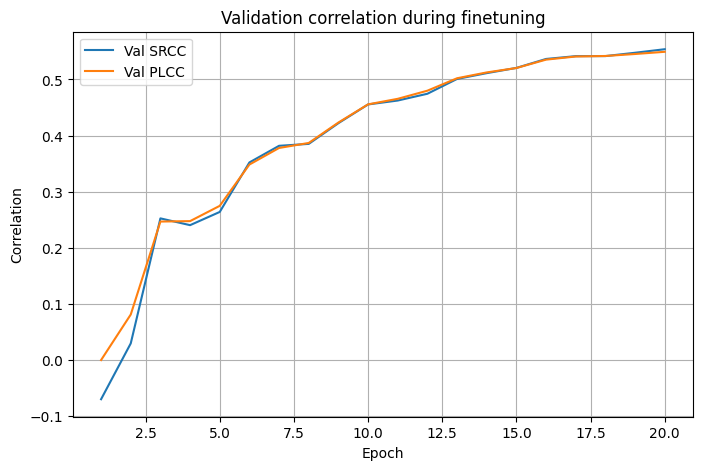

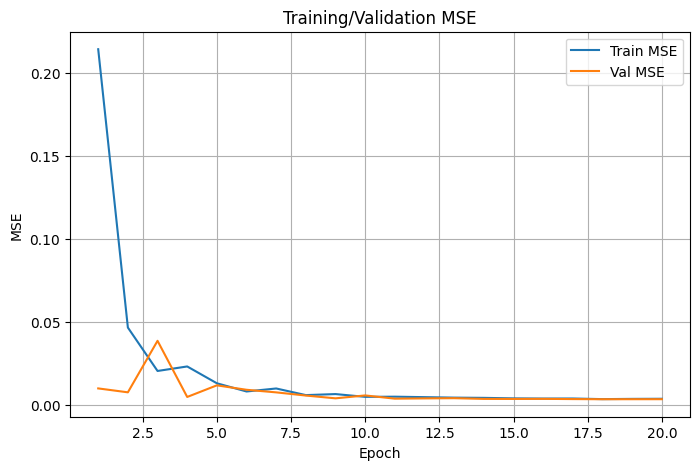

In [76]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["val_srcc"], label="Val SRCC")
plt.plot(history_df["epoch"], history_df["val_plcc"], label="Val PLCC")
plt.xlabel("Epoch")
plt.ylabel("Correlation")
plt.title("Validation correlation during finetuning")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_mse"], label="Train MSE")
plt.plot(history_df["epoch"], history_df["val_mse"], label="Val MSE")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Training/Validation MSE")
plt.legend()
plt.grid(True)
plt.show()